# One-Sided Universal Portfolio for LCB

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

In [2]:
import sys
sys.path.insert(0, "..")

In [31]:
from methods.kt import CoinBettingCI, UnboundedHorseRaceCI, TruncatedHorseRaceCI, TwoHorseRaceCI
from methods.up import BivariateUniversalPortfolioCS, UnboundedUniversalPortfolioCS

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load an example sequence

In [7]:
def generate_bernoulli(t, p, seed=1):
    np.random.seed(seed)
    return (np.random.uniform(size=t) <= p).astype(int)

In [8]:
def generate_beta(t, betas, seed=0):
    np.random.seed(seed)
    return np.random.beta(*betas, size=t)

In [9]:
def generate_exp(t, scale, seed=0):
    np.random.seed(seed)
    return np.random.exponential(scale, size=t)

## 1. How the log(wealth) behaves as a function of $m$

1 5 10 50 100 500 1000 5000 

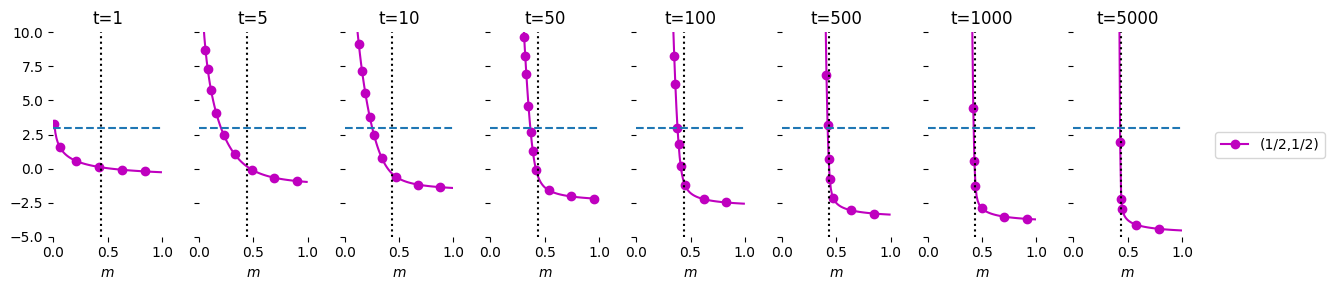

In [84]:
# tlist = [1, 5, 10]
# tlist = [1, 5, 10, 50, 100, 500, 1000]
tlist = [1, 5, 10, 50, 100, 500, 1000, 5000]
tmax = max(tlist)

# upper_bound = 10
# c = 10
# mu0 = 0.25
# xs = generate_bernoulli(t, p=0.25, seed=seed); mu = 0.25; kwd = 'bern0.25'; title = 'Bern(0.25)'
# xs = c * generate_beta(t, betas=[1, 3], seed=seed); mu = c * mu0; kwd = 'beta1,3'; title = 'Beta(1,3)'
# xs = generate_beta(t, betas=[10, 30], seed=seed); mu = 0.25; kwd = 'beta10,30'; title = 'Beta(10,30)' 
# mu = .85; xs = np.random.exponential(size=t, scale=mu); kwd = f'exp({mu})'; title = f'Exp({mu})'

shape = 3.5; scale = 0.125
mu = shape * scale; 
xs = np.random.gamma(shape=shape, scale=scale, size=tmax); kwd = f'Gamma({shape,scale})'; title = f'Gamma({shape,scale})'
# xs = np.random.lognormal(size=t, mean=0, sigma=1); mean=0; sigma=1; mu = np.exp(mean + sigma ** 2 / 2); kwd = 'lognormal0,1'; title = 'LogNormal(0,1)'

fig, axes = plt.subplots(ncols=len(tlist), nrows=1, figsize=(12, 3), sharey=True)

for i, t in enumerate(tlist):
    # TwoHorseRaceCI(betas=(1/2, 1/2)).plot(
    #     delta, xs[:t], every=t, ax=axes[i], **line_configs['KT']
    # )
    # UnboundedHorseRaceCI(betas=(1/2, 1/2)).plot(
    #     delta, xs[:t], upper_bound=1., every=t, ax=axes[i], **line_configs['UnbddKT']
    # )
    # UnboundedUniversalPortfolioCS(betas=(100, 1)).plot(
    #     delta, xs[:t], every=t, ax=axes[i], **line_configs['KT'], label='(100,1)'
    # )
    UnboundedUniversalPortfolioCS(betas=(1/2, 1/2)).plot(
        delta, xs[:t], every=t, ax=axes[i], **line_configs['KT'], label='(1/2,1/2)'
    )

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['bottom'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    
    axes[i].set_xlabel(r'$m$')
    axes[i].set_title('t={}'.format(t))
    axes[i].axvline(x=mu, linestyle='dotted', color='k')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([-5, 10])
# axes[-1].set_ylim([-30, 50])
# axes[-1].set_ylim([-30, 30])
# axes[0].set_ylabel('log(cumulative wealth)')
handles, labels = axes[-1].get_legend_handles_labels()
fig.tight_layout()
fig.legend(handles, labels, 
           loc='center left', 
           bbox_to_anchor=(1, .5),
           ncol=1)

# fig.savefig('figs/ex_wealths_{}.pdf'.format(kwd), bbox_inches='tight')


## 2. Convergence

In [10]:
seed = 0
delta = 0.05

In [11]:
line_configs = dict()
line_configs['CB'] = dict(c='brown', ls='solid', marker='x')
line_configs['KT'] = dict(c='m', ls='solid', marker='o')
line_configs['UnbddKT'] = dict(c='g', ls='solid', marker='o')
line_configs['TruncatedKT'] = dict(c='purple', ls='solid', marker='^')

line_configs['PRECiSE'] = dict(c='tab:pink', ls=(0, (3, 1, 1, 1)), marker='^')
line_configs['UP'] = dict(c='black', ls='-.', markevery=0.1, marker='D')
line_configs['UnbddUP'] = dict(c='g', ls='solid', marker='o')

for key in line_configs:
    line_configs[key]['markevery'] = 0.1

In [69]:
shape = 3.5; scale = 0.125
mu = shape * scale

tmax = 5 * 10 ** 4
lower_cis = []
for _ in range(10):
    xs = np.random.gamma(shape=shape, scale=scale, size=tmax); kwd = f'Gamma({shape,scale})'; title = f'Gamma({shape,scale})'
    # xs = np.random.lognormal(size=t, mean=0, sigma=1); mean=0; sigma=1; mu = np.exp(mean + sigma ** 2 / 2); kwd = 'lognormal0,1'; title = 'LogNormal(0,1)'
    
    lower_ci, *_ = UnboundedUniversalPortfolioCS(betas=(1/2, 1/2)).construct(delta, xs[:tmax], every=tmax)
    lower_cis.append(lower_ci)


  0%|                                                                                                                                                            | 0/50000 [00:00<?, ?it/s]/Users/jongha/Dropbox/src/_gambling/confidence-sequence-via-gambling/notebooks/../methods/up.py:142: RuntimeWarning: divide by zero encountered in log
  return logsumexp(logweights - np.arange(t + 1) * np.log(m + eps))
/Users/jongha/Dropbox/src/_gambling/confidence-sequence-via-gambling/notebooks/../methods/up.py:142: RuntimeWarning: invalid value encountered in multiply
  return logsumexp(logweights - np.arange(t + 1) * np.log(m + eps))
/Users/jongha/Dropbox/src/_gambling/confidence-sequence-via-gambling/notebooks/../methods/up.py:148: RuntimeWarning: divide by zero encountered in log
  base = logweights - np.arange(t + 1) * np.log(m + eps)
/Users/jongha/Dropbox/src/_gambling/confidence-sequence-via-gambling/notebooks/../methods/up.py:148: RuntimeWarning: invalid value encountered in multiply
  base =

(1, 50000)

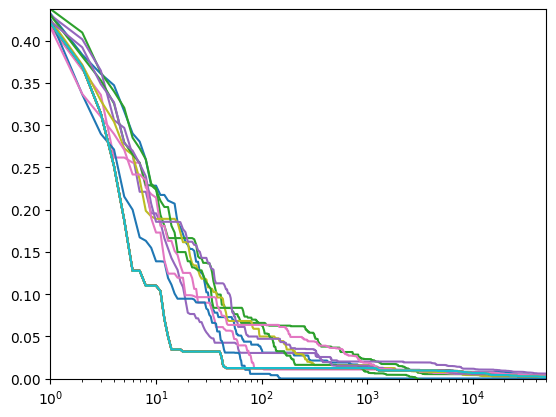

In [80]:
for i in range(len(lower_cis)):
    plt.plot(np.arange(1, tmax + 1), mu - lower_cis[i])
    plt.plot(np.arange(1, tmax + 1), mu - lower_ci)
# plt.yscale('log')
plt.xscale('log')    
plt.ylim([0, mu])
plt.xlim([1, tmax])

## Scratch

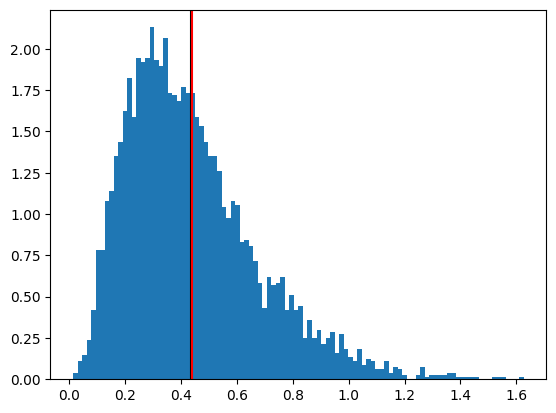

In [16]:
# mu = .85
# xs = np.random.exponential(size=t, scale=mu); kwd = f'exp({mu})'; title = f'Exp({mu})'
plt.hist(xs, bins=100, density=True);
plt.axvline(xs.mean(), c='k')
plt.axvline(mu, c='r')

0.4375


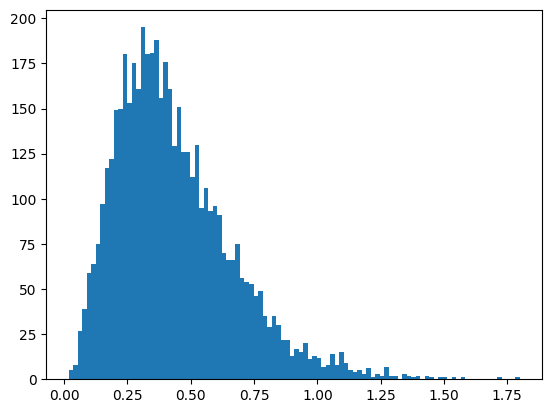

In [17]:
shape = 3.5
scale = 0.125
mu = shape * scale; 
xs = np.random.gamma(shape=shape, scale=scale, size=t); kwd = f'Gamma({shape,scale})'; title = f'Gamma({shape,scale})'
plt.hist(xs, bins=100);
print(mu)
